In [ ]:
#workshopping Historical_FWI.py generalisation 

#first need to recreate the iberia work but more efficient to check data processing is working.



In [ ]:
#cylc stuff 

[task parameters]
    
    member = 1..15

[scheduling]

    [[graph]]
        P1Y = """
            hadgem_historical_fwi<member>
        """

[runtime]
    [[hadgem_historical_fwi<member>]]
        script = """
        set -eux
        conda activate sowf
        cd /data/users/bob.potts/StateOfFires_2025-26/code
        python hadgem_historical_fwi.py
        """

        platform = spice

        [[[directives]]]
            --mem = 100G
            --time = 60
            --cpus-per-task = 1
            --ntasks = 1

In [ ]:
import iris
import os
import numpy as np
from utils.constrain_cubes_standard import *
from utils.cubefuncs import *
import time
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning, module='iris')

In [ ]:

import numpy as np

file_a = "/data/scratch/chantelle.burton/SoW2526/output/ERA5_FWI_1960-2013_Iberia95%.dat"
file_b = "/data/scratch/bob.potts/sowf/test_output/IRIS_ERA5_FWI_1960-2013_Iberia95%.dat"

a = np.loadtxt(file_a)
b = np.loadtxt(file_b)

print("len a:", len(a), "len b:", len(b))
print("first 5 a:", a[:5])
print("first 5 b:", b[:5])
import numpy as np

print("len a:", len(a), "len b:", len(b))
n = min(len(a), len(b))
print("max abs diff:", np.max(np.abs(a[:n]-b[:n])))
print("mean abs diff:", np.mean(np.abs(a[:n]-b[:n])))


In [ ]:
import geopandas as gpd
gdf = gpd.read_file('/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp')
print(gdf.columns)
print(gdf['name'].unique()) 
# Project to a suitable CRS for area calculation (e.g., UTM zone 30N, EPSG:32630)
gdf_proj = gdf.to_crs(epsg=32630)

# Calculate area in square kilometers
gdf_proj['area_km2'] = gdf_proj.area / 1e6

# Show region names and their areas
print(gdf_proj[['name', 'area_km2']])

Colour coord:

Primary Teal:
RGB: 0, 135, 135
HEX: #008787
CMYK: 83, 24, 46, 8

Primary Red:
RGB: 199, 64, 61
HEX: #C7403D
CMYK: 16, 85, 74, 5

Secondary Orange:
RGB: 227, 115, 38
HEX: #E27226
CMYK: 7, 64, 91, 0

Secondary Light Orange:
RGB: 250, 176, 115
HEX: #FAB073
CMYK: 0, 38, 58, 0

Secondary Cream:
RGB: 252, 217, 184
HEX: #FCD9B8
CMYK: 0, 19, 31, 0

Accent colours:

Black 
RGB: 28, 28, 28
HEX: #1C1C1C
CMYK: 0, 0, 0, 100

White:
RGB: 255, 255, 255
HEX: #FFFFFF
CMYK: 0, 0, 0, 0

In [ ]:
cube = iris.load('/data/scratch/bob.potts/sowf/JPA-3Q/836733.tmp-hyb-an-gauss.jra3q.anl_mdl.0_0_0.tmp-hyb-an-gauss.1995091100_1995091518.nc')

c = cube[1]
print(c)
print("\nCoordinates:")
for coord in c.coords():
    print(f"{coord.name()}: {coord.points[:5]} ... {coord.points[-5:]}")
    print(f"  Bounds: {coord.bounds if coord.bounds is not None else 'None'}\n")

In [ ]:
# Plot histograms for Scotland risk ratio bootstrap replicates (corrected vs uncorrected)
import pandas as pd
import matplotlib.pyplot as plt

# File paths
corrected_file = '/data/scratch/bob.potts/sowf/test_output/Exports/Scotland_Risk_Ratio_Bootstrap_Replicates.csv'
uncorrected_file = '/data/scratch/bob.potts/sowf/test_output/Exports/Scotland_Uncorrected_Risk_Ratio_Bootstrap_Replicates.csv'

# Read CSVs
corrected = pd.read_csv(corrected_file)
uncorrected = pd.read_csv(uncorrected_file)

# Plot histograms
plt.figure(figsize=(8,5))
plt.hist(corrected['rr_replicates'], bins=50, alpha=0.6, label='Bias Corrected', color='#008787')
plt.hist(uncorrected['rr_replicates'], bins=50, alpha=0.6, label='Uncorrected', color='#C7403D')
plt.xlabel('Risk Ratio')
plt.ylabel('Frequency')
plt.title('Scotland Risk Ratio Bootstrap Replicates')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt

# Load the SST data
sea_sst_pp = iris.load('/data/users/hadobs/cma_datasets/hadsst4/HadSST.4.0.1.0/pp/ENSEMBLE/1/ACTUAL_SST_realisation_1.pp')
sea_sst_pp_cube = sea_sst_pp[0]  # monthly time steps

# Get the time coordinate and convert to datetime objects
time_coord = sea_sst_pp_cube.coord('time')
time_datetimes = time_coord.units.num2date(time_coord.points)
print(time_datetimes[:5],'\n' ,time_datetimes[-5:])  # Print first and last 5 time points

# Extract indices for 2023 and 2024
indices_2023 = [i for i, t in enumerate(time_datetimes) if t.year == 2023]
indices_2024 = [i for i, t in enumerate(time_datetimes) if t.year == 2024]

# Compute means for 2023 and 2024
sst_2023_mean = sea_sst_pp_cube[indices_2023].collapsed('time', iris.analysis.MEAN) if indices_2023 else None
sst_2024_mean = sea_sst_pp_cube[indices_2024].collapsed('time', iris.analysis.MEAN) if indices_2024 else None

# Extract the final timestep and its date
final_timestep = sea_sst_pp_cube[-1]
final_time_point = time_datetimes[-1]

# Plot the final timestep
plt.figure(figsize=(8,4))
qplt.contourf(final_timestep, 20)
plt.colorbar()
plt.gca().coastlines()
plt.title(f'Final Timestep SST ({final_time_point.strftime("%Y-%m-%d")})')
plt.show()

# Plot 2023 mean if available
if sst_2023_mean is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_2023_mean, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Mean for 2023')
    plt.show()

# Plot 2024 mean if available
if sst_2024_mean is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_2024_mean, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Mean for 2024')
    plt.show()

# Plot difference: final timestep minus 2023 mean
if sst_2023_mean is not None:
    sst_diff_2023 = final_timestep - sst_2023_mean
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_diff_2023, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title(f'SST Difference: Final ({final_time_point.strftime("%Y-%m-%d")}) minus 2023 Mean')
    plt.show()

# Plot difference: final timestep minus 2024 mean
if sst_2024_mean is not None:
    sst_diff_2024 = final_timestep - sst_2024_mean
    plt.figure(figsize=(8,4))
    qplt.contourf(sst_diff_2024, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title(f'SST Difference: Final ({final_time_point.strftime("%Y-%m-%d")}) minus 2024 Mean')
    plt.show()

# --- Additional: Compare February 2025 to February 2024 and 2023 ---
# Find indices for February 2023, 2024, and 2025
feb_2023_idx = next((i for i, t in enumerate(time_datetimes) if t.year == 2023 and t.month == 2), None)
feb_2024_idx = next((i for i, t in enumerate(time_datetimes) if t.year == 2024 and t.month == 2), None)
feb_2025_idx = next((i for i, t in enumerate(time_datetimes) if t.year == 2025 and t.month == 2), None)

# Plot February 2023, 2024, 2025 if available
if feb_2023_idx is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sea_sst_pp_cube[feb_2023_idx], 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST February 2023')
    plt.show()
if feb_2024_idx is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sea_sst_pp_cube[feb_2024_idx], 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST February 2024')
    plt.show()
if feb_2025_idx is not None:
    plt.figure(figsize=(8,4))
    qplt.contourf(sea_sst_pp_cube[feb_2025_idx], 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST February 2025')
    plt.show()

# Plot differences: Feb 2025 minus Feb 2023 and Feb 2024
if feb_2025_idx is not None and feb_2023_idx is not None:
    diff_25_23 = sea_sst_pp_cube[feb_2025_idx] - sea_sst_pp_cube[feb_2023_idx]
    plt.figure(figsize=(8,4))
    qplt.contourf(diff_25_23, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Difference: Feb 2025 minus Feb 2023')
    plt.show()
if feb_2025_idx is not None and feb_2024_idx is not None:
    diff_25_24 = sea_sst_pp_cube[feb_2025_idx] - sea_sst_pp_cube[feb_2024_idx]
    plt.figure(figsize=(8,4))
    qplt.contourf(diff_25_24, 20)
    plt.colorbar()
    plt.gca().coastlines()
    plt.title('SST Difference: Feb 2025 minus Feb 2024')
    plt.show()

In [ ]:
import iris

fwi_cube = iris.load('/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI_2020s.nc')
print(fwi_cube[0])

In [ ]:
import re
import iris
import numpy as np
from datetime import datetime, timedelta
import iris.coords
from utils.constrain_cubes_standard import *

# --- CONFIG ---
shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
shape_name = 'Chilean Temperate Forests and Matorral'  # Change as needed

# --- FUNCTION: Remap time from filename ---
def remap_time_from_filename(cube, filename):
    match = re.search(r'FWI_(\d{4})s', filename)
    if not match:
        raise ValueError("Could not extract decade from filename")
    start_year = int(match.group(1))
    n_times = cube.shape[0]
    dates = [datetime.datetime(start_year, 1, 1) + timedelta(days=i) for i in range(n_times)]
    time_unit = 'days since 1970-01-01 00:00:00'
    time_points = np.array([(d - datetime(1970, 1, 1)).days for d in dates])
    time_coord = iris.coords.DimCoord(time_points, standard_name='time', units=time_unit)
    # Replace the time coordinate
    cube.remove_coord('forecast_reference_time')
    cube.add_dim_coord(time_coord, 0)
    return cube

# --- LOAD AND REMAP ---
f = '/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI_2020s.nc'
cube = iris.load_cube(f)
cube = remap_time_from_filename(cube, f)

# --- CUT TO SHAPEFILE ---
cube_cut = contrain_to_sow_shapefile(cube, shp_file, shape_name)
print(cube_cut)


In [ ]:
#Country = 'Scotland'
import iris
import warnings
import matplotlib.pyplot as plt 
import iris.quickplot as qplt
warnings.filterwarnings("ignore", category=UserWarning, module='iris')
warnings.filterwarnings("ignore", category=FutureWarning, module='iris')
from utils.constrain_cubes_standard import *
from utils.cubefuncs import GetERA5Threshold, CountryPercentile, TimePercentile
print('Running Scotland')

shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
Month = 7
month = 'July'
percentile = 95
shape_name = 'Scottish Highlands'
ERA5_2025 = '/data/scratch/chantelle.burton/SoW2526/Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc'
from utils.cubefuncs import GetERA5Threshold

# threshold_ERA5_2025 = GetERA5Threshold(ERA5_2025, shp_file, shape_name, Month, percentile)
# print(f"ERA5 2025 {month} {percentile}th percentile threshold for {shape_name}: {threshold_ERA5_2025}") #5.208984374999998

era5_cube = iris.load_cube(ERA5_2025, 'canadian_fire_weather_index')
#print(era5_cube)
# 1. Apply month constraint FIRST (matching original)
if isinstance(Month, tuple):
    daterange = iris.Constraint(time=lambda cell: cell.point.month in Month)
else:
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)

era5_cube = era5_cube.extract(daterange)
#print(era5_cube)
# 2. Apply shapefile mask
era5_cube = contrain_to_sow_shapefile(era5_cube, shp_file, shape_name)
#print(era5_cube)
plt.figure(figsize=(8, 6))
qplt.contourf(era5_cube[0], 20)
plt.gca().coastlines()
plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025)")
plt.colorbar(label='FWI')
# Plot every timestep in the cube
for i, t in enumerate(era5_cube.slices_over('time')):
    plt.figure(figsize=(8, 6))
    qplt.contourf(t, 20)
    plt.gca().coastlines()
    plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025) - Timestep {i+1}")
    plt.colorbar(label='FWI')
    plt.show()
# 3. Spatial percentile
era5_cube = CountryPercentile(era5_cube, percentile)



# 4. Temporal percentile
era5_cube = TimePercentile(era5_cube, percentile)
print(era5_cube.data)
print(float(np.array(era5_cube.data)))


In [2]:
import iris

fwi_grib_cube = iris.load_cube('/data/scratch/bob.potts/sowf/ERA5_Checks/ERA5_FWI/FWI-2020-2025.grib')
print(fwi_grib_cube)

TranslationError: Identificaton section 1 contains an unsupported significance of reference time [4]

In [ ]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import shape, Polygon, MultiPolygon
import numpy as np
import geopandas as gpd

# Load the cube as before
era5_cube = iris.load_cube(ERA5_2025, 'canadian_fire_weather_index')

# Apply month constraint
if isinstance(Month, tuple):
    daterange = iris.Constraint(time=lambda cell: cell.point.month in Month)
else:
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)
era5_cube = era5_cube.extract(daterange)

# Get Natural Earth admin_1 states/provinces at 10m resolution
ne_gdf = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
scotland_poly = ne_gdf[(ne_gdf['name'] == 'United Kingdom')].geometry.values[0]

# Scotland is not a separate country in Natural Earth lowres, so use a bounding box or a custom mask.
# For a more precise mask, use Natural Earth admin_1 (states/provinces) dataset:
admin1 = gpd.read_file('https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/50m/cultural/ne_50m_admin_1_states_provinces.shp')
scotland_admin1 = admin1[admin1['name'].str.contains('Scotland')]
scotland_union = scotland_admin1.unary_union

# Mask the cube using the Scotland polygon
lats = era5_cube.coord('latitude').points
lons = era5_cube.coord('longitude').points
lon_grid, lat_grid = np.meshgrid(lons, lats)
points = np.vstack((lon_grid.flatten(), lat_grid.flatten())).T
mask = np.array([scotland_union.contains(shape({'type':'Point','coordinates':(x,y)})) for x,y in points])
mask = mask.reshape(lat_grid.shape)

# Apply mask to each time slice
masked_data = np.ma.masked_array(era5_cube.data, mask=np.broadcast_to(~mask, era5_cube.data.shape))

# Plot the first timestep for Scotland region
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
qplt.contourf(era5_cube[0], 20, axes=ax)
ax.add_geometries([scotland_union], ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=2)
ax.coastlines()
ax.set_extent([-8, -0.5, 54.5, 61])
plt.title(f"Scotland (Cartopy Natural Earth) - ERA5 {month} {percentile}th Percentile FWI (2025)")
plt.colorbar(label='FWI')
plt.show()

In [ ]:
#Country = 'Scotland'
import iris
import warnings
import matplotlib.pyplot as plt 
import iris.quickplot as qplt
warnings.filterwarnings("ignore", category=UserWarning, module='iris')
warnings.filterwarnings("ignore", category=FutureWarning, module='iris')
from utils.constrain_cubes_standard import *
from utils.cubefuncs import GetERA5Threshold, CountryPercentile, TimePercentile
print('Running Scotland')

shp_file = '/data/users/chantelle.burton/Attribution/StateOfFires_2025-26/SoW2526_Focal_MASTER_20260218.shp'
Month = 7
month = 'July'
percentile = 95
shape_name = 'Scottish Highlands'
ERA5_2025 = '/data/scratch/chantelle.burton/SoW2526/Y2526FWI/FWI_ERA5_std_reanalysis_2025-06-01-2025-10-01_global_day_initialise-from=previous-and-use-numpy=False-and-code-src=copernicus-and-save-input-data=True.nc'
from utils.cubefuncs import GetERA5Threshold

# threshold_ERA5_2025 = GetERA5Threshold(ERA5_2025, shp_file, shape_name, Month, percentile)
# print(f"ERA5 2025 {month} {percentile}th percentile threshold for {shape_name}: {threshold_ERA5_2025}") #5.208984374999998

era5_cube = iris.load_cube(ERA5_2025, 'canadian_fire_weather_index')
#print(era5_cube)
# 1. Apply month constraint FIRST (matching original)
if isinstance(Month, tuple):
    daterange = iris.Constraint(time=lambda cell: cell.point.month in Month)
else:
    daterange = iris.Constraint(time=lambda cell: cell.point.month == Month)

era5_cube = era5_cube.extract(daterange)
#print(era5_cube)
# 2. Apply shapefile mask
era5_cube = contrain_to_sow_shapefile(era5_cube, shp_file, shape_name)
#print(era5_cube)
plt.figure(figsize=(8, 6))
qplt.contourf(era5_cube[0], 20)
plt.gca().coastlines()
plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025)")
plt.colorbar(label='FWI')
# Plot every timestep in the cube
for i, t in enumerate(era5_cube.slices_over('time')):
    plt.figure(figsize=(8, 6))
    qplt.contourf(t, 20)
    plt.gca().coastlines()
    plt.title(f"{shape_name} - ERA5 {month} {percentile}th Percentile FWI (2025) - Timestep {i+1}")
    plt.colorbar(label='FWI')
    plt.show()
# 3. Spatial percentile
era5_cube = CountryPercentile(era5_cube, percentile)



# 4. Temporal percentile
era5_cube = TimePercentile(era5_cube, percentile)
print(era5_cube.data)
print(float(np.array(era5_cube.data)))


In [15]:
import numpy as np

# Calculate and print statistics for both distributions

data1_np = np.array(data1)
data2_np = np.array(data2)
data3_np = np.array(data3)

def print_stats(data, label):
    print(f"Stats for {label}:")
    print(f"  Count: {len(data)}")
    print(f"  Mean: {np.mean(data):.4f}")
    print(f"  Median: {np.median(data):.4f}")
    print(f"  Std: {np.std(data):.4f}")
    print(f"  Min: {np.min(data):.4f}")
    print(f"  Max: {np.max(data):.4f}")
    print(f"  5th percentile: {np.percentile(data, 5):.4f}")
    print(f"  95th percentile: {np.percentile(data, 95):.4f}\n")

print_stats(data1_np, "July Only")
print_stats(data2_np, "Dual Months")
print_stats(data3_np, "June Only")

Stats for July Only:
  Count: 54
  Mean: 5.8945
  Median: 5.8242
  Std: 2.7238
  Min: 1.0059
  Max: 11.4590
  5th percentile: 1.9864
  95th percentile: 10.5774

Stats for Dual Months:
  Count: 54
  Mean: 6.6192
  Median: 6.4004
  Std: 2.2916
  Min: 2.6953
  Max: 11.2656
  5th percentile: 3.3445
  95th percentile: 10.4727

Stats for June Only:
  Count: 54
  Mean: 6.3884
  Median: 6.1986
  Std: 2.4129
  Min: 2.6852
  Max: 11.7244
  5th percentile: 3.1495
  95th percentile: 10.4203



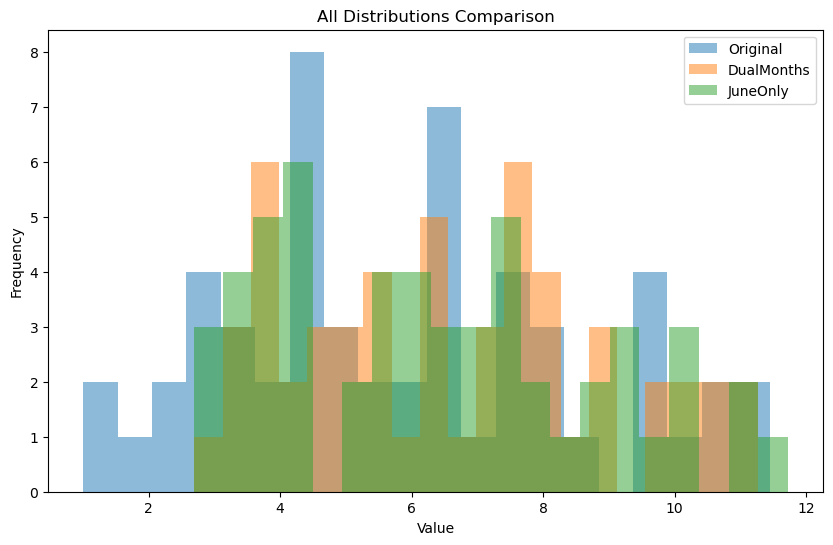

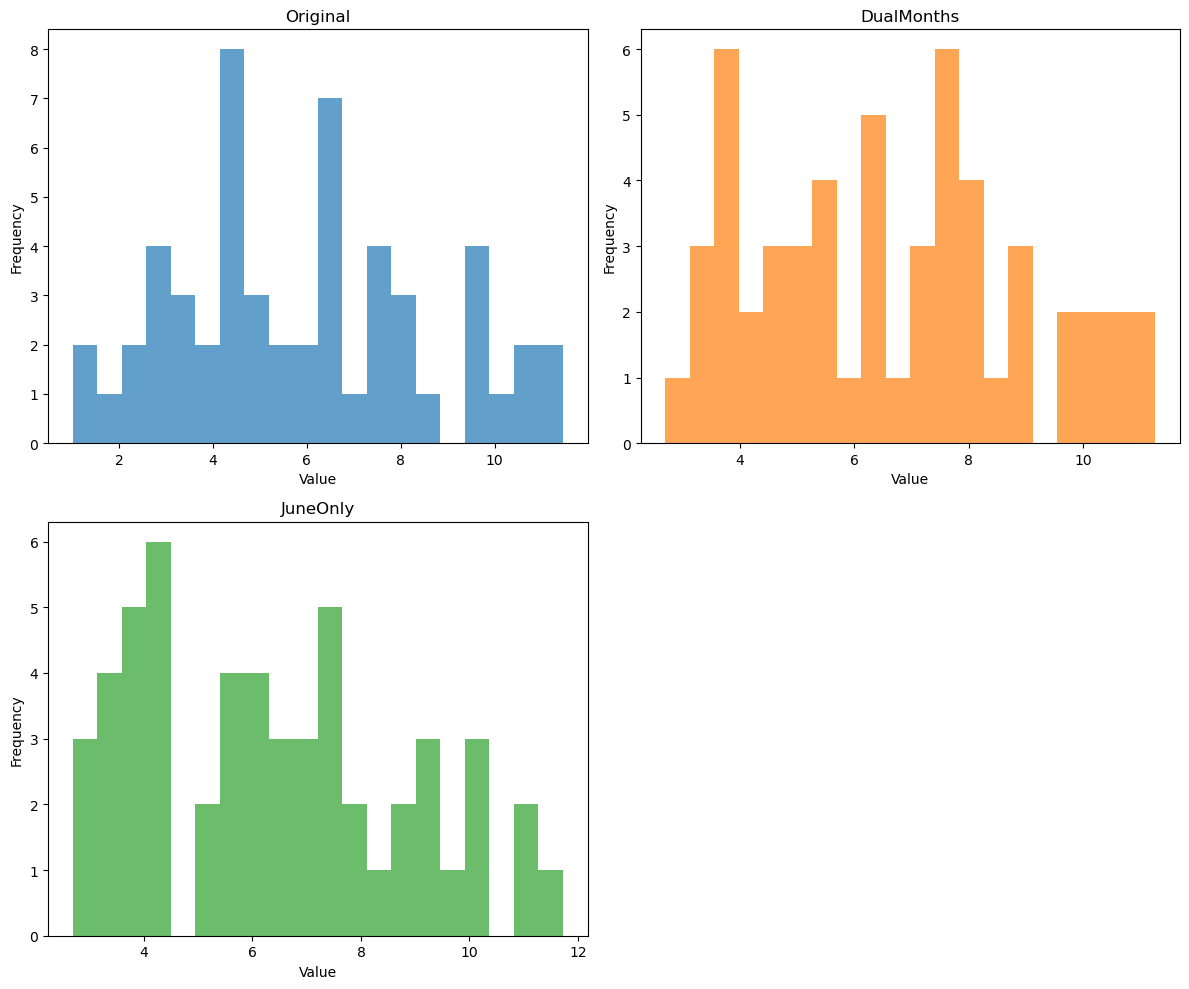

In [ ]:
import matplotlib.pyplot as plt

# Plot all three distributions on one figure
plt.figure(figsize=(10,6))
plt.hist(data1, bins=20, alpha=0.5, label='JulyOnly')
plt.hist(data2, bins=20, alpha=0.5, label='DualMonths')
plt.hist(data3, bins=20, alpha=0.5, label='JuneOnly')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('All Distributions Comparison')
plt.legend()
plt.show()

# Plot each distribution individually in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

axs[0].hist(data1, bins=20, alpha=0.7, color='C0')
axs[0].set_title('Original')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Frequency')

axs[1].hist(data2, bins=20, alpha=0.7, color='C1')
axs[1].set_title('DualMonths')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Frequency')

axs[2].hist(data3, bins=20, alpha=0.7, color='C2')
axs[2].set_title('JuneOnly')
axs[2].set_xlabel('Value')
axs[2].set_ylabel('Frequency')

# Hide the unused subplot (bottom right)
axs[3].axis('off')

plt.tight_layout()
plt.show()

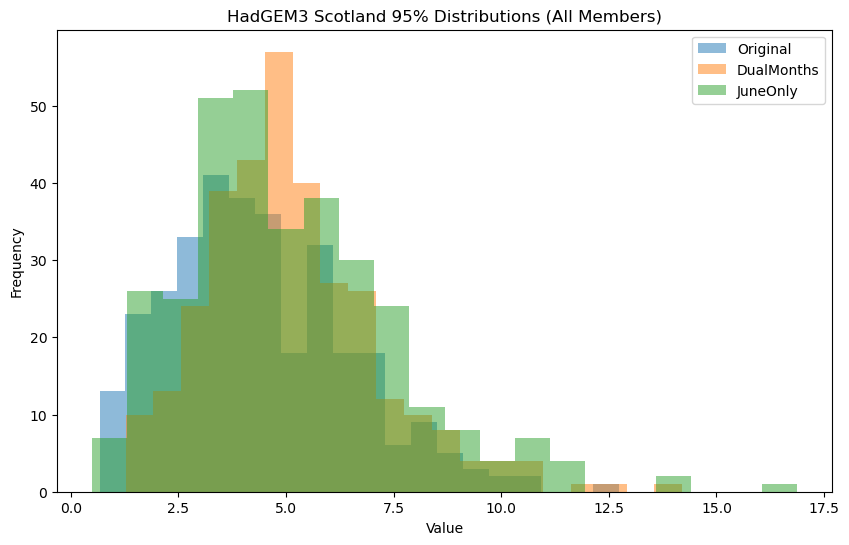

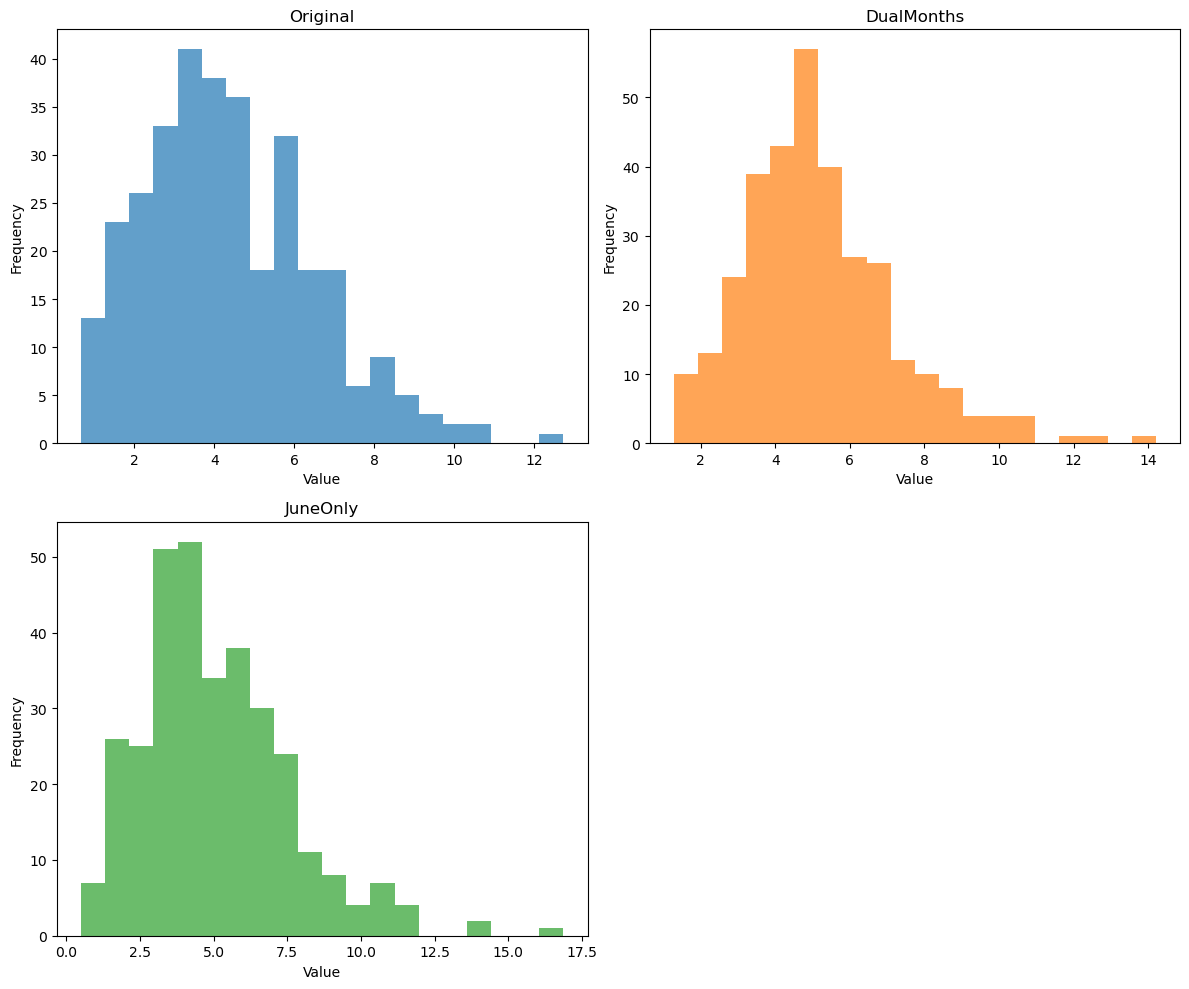

In [13]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# File patterns for each group
orig_pattern = "/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_[1-9,1][0-5]_95%.dat"
updated_pattern = "/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_Updated_[1-9,1][0-5]_95%.dat"
june_pattern = "/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_JuneOnly_[1-9,1][0-5]_95%.dat"

# Helper to load and concatenate all .dat files for a pattern
def load_group(pattern):
    files = sorted(glob.glob(pattern))
    data = []
    for f in files:
        try:
            arr = np.loadtxt(f)
            data.append(arr)
        except Exception as e:
            print(f"Error loading {f}: {e}")
    if data:
        return np.concatenate(data)
    else:
        return np.array([])

# Load all groups
data_orig = load_group("/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_[1-9,1][0-5]_95%.dat")
data_updated = load_group("/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_Updated_[1-9,1][0-5]_95%.dat")
data_june = load_group("/data/scratch/bob.potts/sowf/test_output/Baseline/HadGEM3_FWI_1960-2013_Scotland_JuneOnly_[1-9,1][0-5]_95%.dat")

# Plot all on one figure
plt.figure(figsize=(10,6))
plt.hist(data_orig, bins=20, alpha=0.5, label='Original')
plt.hist(data_updated, bins=20, alpha=0.5, label='DualMonths')
plt.hist(data_june, bins=20, alpha=0.5, label='JuneOnly')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('HadGEM3 Scotland 95% Distributions (All Members)')
plt.legend()
plt.show()

# Plot each group individually in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()
axs[0].hist(data_orig, bins=20, alpha=0.7, color='C0')
axs[0].set_title('Original')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Frequency')
axs[1].hist(data_updated, bins=20, alpha=0.7, color='C1')
axs[1].set_title('DualMonths')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Frequency')
axs[2].hist(data_june, bins=20, alpha=0.7, color='C2')
axs[2].set_title('JuneOnly')
axs[2].set_xlabel('Value')
axs[2].set_ylabel('Frequency')
axs[3].axis('off')
plt.tight_layout()
plt.show()